# Machine Learning models for public transport route choice prediction in Santiago, Chile

Last reviewed: Monday 18-05-2026

Times this file has been edited: 2

Hardware specs:


1. *Portable* branch:
    * Machine: MacBook Air (13-inch, 2017)
    * OS: MacOS Monterey v12.7.6
    * CPU: 1.8 GHz Intel Core i5 de dos núcleos
    * RAM: 8 GB 1600 MHz DDR3
    * Graphics: Intel HD Graphics 6000 1536 MB

2. *House* branch:
    * OS: Windows 10 Home 64-bit (10.0, Build 19045)
    * Processor: Intel(R) Core(TM) i7-8700K CPU @ 3.70GHz (12 CPUs), ~3.7GHz
    * Memory: 12288MB RAM
    * GPU: NVIDIA GeForce RTX 3060 12115 MB

## Model 1: Random Forest

### Modelo v1.1.0: Predicción binaria de ruta elegida en horario punta mañana (06:30-09:00)

In [ ]:
"""
Modelo 1.1.0: Random Forest para elección de ruta
Train: Trips 2024 punta mañana (25% muestreado por id_obs)
Test:  Trips 2025 punta mañana (completo)
"""

import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss
import joblib
import json
from datetime import datetime

# ── Rutas ────────────────────────────────────────────────────────────────────
BASE_DIR     = Path(r"D:\GitHub\tesis_magister_route_choice_modelling")
FEATURES_DIR = BASE_DIR / "data" / "parquets" / "04_features"
MODELS_DIR   = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

DATASET = str(
    FEATURES_DIR / "dataset_modelado_v2.parquet"
).replace("\\", "/")

# ── Configuración ─────────────────────────────────────────────────────────────
FEATURES = [
    "tviaje_min",            # tiempo total del viaje
    "tiempo_espera_min",     # tiempo de espera total
    "tiempo_invehiculo_min", # tiempo en vehículo total
    "tiempo_caminata_min",   # tiempo de caminata en transbordos
    "n_transbordos",         # número de transbordos
    "tiene_metro",           # ¿incluye Metro?
    "dist_caminata_km",      # distancia caminada en transbordos
    "llueve",                # ¿está lloviendo?
    "temperature_2m",        # temperatura en °C
    "n_obs_ruta",            # popularidad observada de la ruta
]

TARGET         = "elegida"
TRAIN_FRAC     = 0.25
RANDOM_STATE   = 42

RF_PARAMS = {
    "n_estimators":    100,
    "max_depth":       10,
    "min_samples_leaf": 50,
    "class_weight":    "balanced",
    "n_jobs":          -1,
    "random_state":    RANDOM_STATE,
}


# ── Helpers ───────────────────────────────────────────────────────────────────

def hit_rate(df_eval: pd.DataFrame, y_prob: np.ndarray) -> float:
    """
    Fracción de viajes donde la alternativa con mayor probabilidad
    predicha coincide con la alternativa realmente elegida.
    Métrica estándar en modelos de elección discreta.
    """
    df = df_eval[["id_obs", TARGET]].copy()
    df["prob"] = y_prob
    idx_max = df.groupby("id_obs")["prob"].idxmax()
    return float(df.loc[idx_max, TARGET].mean())


def null_hit_rate(df_eval: pd.DataFrame) -> float:
    """
    Hit rate de referencia: un modelo que asigna igual probabilidad
    a todas las alternativas. Equivale a elegir al azar.
    = proporción de filas con elegida=1 = 1 / tamaño_promedio_CS
    """
    return float(df_eval[TARGET].mean())


# ── Carga de datos ────────────────────────────────────────────────────────────

def cargar_split(
    con: duckdb.DuckDBPyConnection,
    anio: str,
    sample_frac: float = 1.0
) -> pd.DataFrame:
    """
    Carga datos de un año. Si sample_frac < 1, muestrea esa fracción
    de id_obs únicos (preserva la estructura de elección completa
    para cada observación muestreada).
    """
    cols_select = ", ".join(["id_obs", TARGET] + FEATURES)

    if sample_frac < 1.0:
        # Obtener todos los id_obs del año
        todos_ids = con.sql(f"""
            SELECT DISTINCT id_obs
            FROM read_parquet('{DATASET}')
            WHERE fecha LIKE '{anio}%'
        """).df()["id_obs"].values

        n_sample = int(len(todos_ids) * sample_frac)
        np.random.seed(RANDOM_STATE)
        ids_muestra = np.random.choice(todos_ids, n_sample, replace=False)

        con.register(
            "ids_muestra_tmp",
            pd.DataFrame({"id_obs": ids_muestra})
        )

        df = con.sql(f"""
            SELECT {cols_select}
            FROM read_parquet('{DATASET}') d
            INNER JOIN ids_muestra_tmp s USING (id_obs)
        """).df()

        con.execute("DROP VIEW IF EXISTS ids_muestra_tmp")
    else:
        df = con.sql(f"""
            SELECT {cols_select}
            FROM read_parquet('{DATASET}')
            WHERE fecha LIKE '{anio}%'
        """).df()

    # Rellenar nulos en features con mediana del split
    for col in FEATURES:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    return df

In [2]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────

print("=" * 60)
print("MODELO 01 — RANDOM FOREST")
print("=" * 60)

con = duckdb.connect()
con.execute("SET memory_limit = '3GB'")
con.execute("SET threads = 6")
con.execute("SET temp_directory = 'D:/temp_duckdb'")

# Cargar datos
print(f"\n[1/4] Cargando datos...")
df_train = cargar_split(con, "2024", sample_frac=TRAIN_FRAC)
df_test  = cargar_split(con, "2025", sample_frac=1.0)
con.close()

print(f"  Train (2024, {int(TRAIN_FRAC*100)}% obs): {len(df_train):,} filas "
      f"| {df_train['id_obs'].nunique():,} observaciones")
print(f"  Test  (2025, 100% obs):  {len(df_test):,} filas "
      f"| {df_test['id_obs'].nunique():,} observaciones")
print(f"  Balance train — elegida=1: {df_train[TARGET].mean()*100:.1f}%")
print(f"  Balance test  — elegida=1: {df_test[TARGET].mean()*100:.1f}%")

# Preparar matrices
X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values
X_test  = df_test[FEATURES].values
y_test  = df_test[TARGET].values

# Entrenar
print(f"\n[2/4] Entrenando Random Forest...")
print(f"  Parámetros: {RF_PARAMS}")
t0 = datetime.now()

modelo = RandomForestClassifier(**RF_PARAMS)
modelo.fit(X_train, y_train)

t1 = datetime.now()
print(f"  Tiempo de entrenamiento: {(t1-t0).seconds}s")

# Predecir probabilidades
print(f"\n[3/4] Evaluando...")
y_prob_train = modelo.predict_proba(X_train)[:, 1]
y_prob_test  = modelo.predict_proba(X_test)[:, 1]

# Métricas
hr_null  = null_hit_rate(df_test)
hr_train = hit_rate(df_train, y_prob_train)
hr_test  = hit_rate(df_test,  y_prob_test)
hr_adj   = (hr_test - hr_null) / (1 - hr_null)  # mejora sobre azar

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

ll_train  = log_loss(y_train, y_prob_train)
ll_test   = log_loss(y_test,  y_prob_test)

print(f"\n  {'Métrica':<35} {'Train':>10} {'Test':>10}")
print(f"  {'-'*55}")
print(f"  {'Hit Rate (modelo)':<35} {hr_train*100:>9.1f}% {hr_test*100:>9.1f}%")
print(f"  {'Hit Rate null (azar)':<35} {hr_null*100:>9.1f}% {hr_null*100:>9.1f}%")
print(f"  {'Hit Rate ajustado (vs azar)':<35} {'':>10} {hr_adj*100:>9.1f}%")
print(f"  {'AUC-ROC':<35} {auc_train:>10.4f} {auc_test:>10.4f}")
print(f"  {'Log-Loss':<35} {ll_train:>10.4f} {ll_test:>10.4f}")

# Importancia de features
print(f"\n[4/4] Importancia de variables:")
importancias = pd.DataFrame({
    "feature":    FEATURES,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

for _, row in importancias.iterrows():
    barra = "█" * int(row["importance"] * 200)
    print(f"  {row['feature']:<30} {row['importance']:.4f}  {barra}")

# Guardar modelo y resultados
nombre_modelo = "rf_01_punta_manana"
joblib.dump(modelo, MODELS_DIR / f"{nombre_modelo}.pkl")

resultados = {
    "modelo":         nombre_modelo,
    "fecha_train":    str(datetime.now()),
    "train_anio":     "2024",
    "test_anio":      "2025",
    "train_frac":     TRAIN_FRAC,
    "train_filas":    len(df_train),
    "test_filas":     len(df_test),
    "features":       FEATURES,
    "params":         RF_PARAMS,
    "metricas": {
        "hit_rate_null":     round(hr_null,  4),
        "hit_rate_test":     round(hr_test,  4),
        "hit_rate_ajustado": round(hr_adj,   4),
        "auc_test":          round(auc_test, 4),
        "log_loss_test":     round(ll_test,  4),
    }
}

MODELO 01 — RANDOM FOREST

[1/4] Cargando datos...
  Train (2024, 25% obs): 2,164,907 filas | 383,135 observaciones
  Test  (2025, 100% obs):  9,291,592 filas | 1,640,931 observaciones
  Balance train — elegida=1: 17.7%
  Balance test  — elegida=1: 17.7%

[2/4] Entrenando Random Forest...
  Parámetros: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 50, 'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42}
  Tiempo de entrenamiento: 88s

[3/4] Evaluando...

  Métrica                                  Train       Test
  -------------------------------------------------------
  Hit Rate (modelo)                        65.9%      65.4%
  Hit Rate null (azar)                     17.7%      17.7%
  Hit Rate ajustado (vs azar)                         58.0%
  AUC-ROC                                 0.8450     0.8432
  Log-Loss                                0.4502     0.4523

[4/4] Importancia de variables:
  n_obs_ruta                     0.5307  ███████████████████████████

### SHAP values

Calculando SHAP values sobre muestra de 3000 observaciones...
  Shape SHAP values (clase elegida): (3000, 10)  → esperado (3000, 10)


C:\Users\seba\AppData\Local\Temp\ipykernel_33924\3955466202.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_shap, feature_names=FEATURES, show=False)


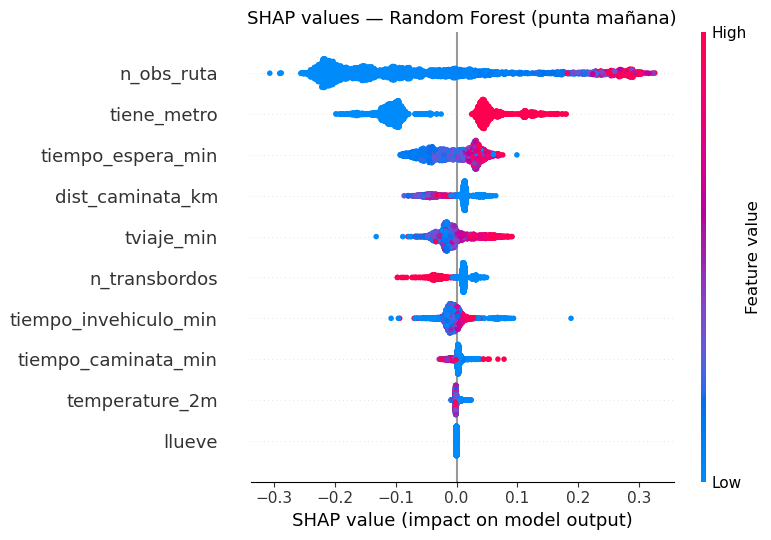

C:\Users\seba\AppData\Local\Temp\ipykernel_33924\3955466202.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_shap, feature_names=FEATURES, plot_type="bar", show=False)


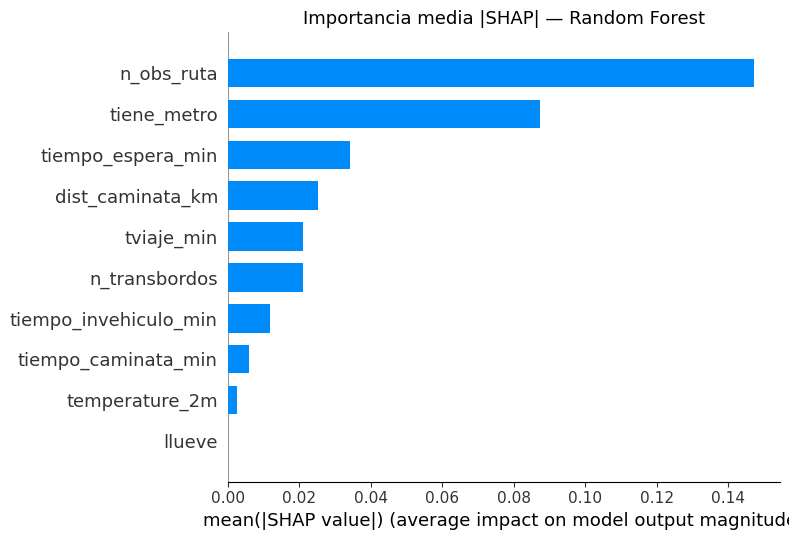


Importancia media |SHAP| por variable:
              feature  mean_abs_shap
           n_obs_ruta       0.147044
          tiene_metro       0.087452
    tiempo_espera_min       0.034294
     dist_caminata_km       0.025398
           tviaje_min       0.021143
        n_transbordos       0.021063
tiempo_invehiculo_min       0.011791
  tiempo_caminata_min       0.005887
       temperature_2m       0.002606
               llueve       0.000000


In [6]:
import shap
import matplotlib.pyplot as plt

# ── Muestra representativa para SHAP (test set es demasiado grande) ───────────
N_SHAP = 3000
rng    = np.random.default_rng(RANDOM_STATE)
idx_shap = rng.choice(len(X_test), N_SHAP, replace=False)
X_shap   = X_test[idx_shap]

# ── Calcular SHAP values con TreeExplainer ────────────────────────────────────
print(f"Calculando SHAP values sobre muestra de {N_SHAP} observaciones...")
explainer   = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_shap)

# Normalizar output: SHAP >=0.46 devuelve array 3D (n_obs, n_feat, n_clases);
# versiones anteriores devolvían lista [clase_0, clase_1].
if isinstance(shap_values, list):
    sv = shap_values[1]                  # lista[1] → clase "elegida=1"
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]            # (n_obs, n_feat, n_clases)[:,:,1]
else:
    sv = shap_values

print(f"  Shape SHAP values (clase elegida): {sv.shape}  → esperado ({N_SHAP}, {len(FEATURES)})")

# ── Plot 1: Beeswarm (resumen global) ─────────────────────────────────────────
shap.summary_plot(sv, X_shap, feature_names=FEATURES, show=False)
plt.title("SHAP values — Random Forest (punta mañana)", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "rf_01_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Importancia media |SHAP| ─────────────────────────────────────────
shap.summary_plot(sv, X_shap, feature_names=FEATURES, plot_type="bar", show=False)
plt.title("Importancia media |SHAP| — Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "rf_01_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────────────
shap_mean = pd.DataFrame({
    "feature":       FEATURES,
    "mean_abs_shap": np.abs(sv).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nImportancia media |SHAP| por variable:")
print(shap_mean.to_string(index=False))


## Modelo 2: XGBoost

In [7]:
"""
Modelo 2.1.0: XGBoost para elección de ruta
Train: Trips 2024 punta mañana (25% muestreado por id_obs)
Test:  Trips 2025 punta mañana (completo)

Features adicionales respecto al RF baseline:
  - Tiempos desagregados por etapa (te0, tv1, tc1, ...)
  - Distancias (euclidiana, ruta, caminata, en vehículo)
  - Contexto temporal (periodo_inicio_viaje, mediahora_num, tipodia)
  - Clima completo (lluvia_intensa, wind_speed_10m, relative_humidity_2m)
"""

import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, log_loss
import joblib
import json
from datetime import datetime

# ── Rutas ─────────────────────────────────────────────────────────────────────
BASE_DIR     = Path(r"D:\GitHub\tesis_magister_route_choice_modelling")
FEATURES_DIR = BASE_DIR / "data" / "parquets" / "04_features"
MODELS_DIR   = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

DATASET = str(
    FEATURES_DIR / "dataset_modelado_v2.parquet"
).replace("\\", "/")

# ── Features ──────────────────────────────────────────────────────────────────
FEATURES_XGB = [
    # Popularidad y estructura de ruta
    "n_obs_ruta",              # observaciones históricas de la ruta en este OD
    "tiene_metro",             # ¿la ruta incluye Metro?
    "n_transbordos",           # cantidad de transbordos
    # Tiempos agregados
    "tviaje_min",              # tiempo total del viaje (min)
    "tiempo_espera_min",       # tiempo de espera total
    "tiempo_invehiculo_min",   # tiempo en vehículo total
    "tiempo_caminata_min",     # tiempo de caminata total
    # Tiempos por etapa (NaN cuando la etapa no existe → XGBoost los maneja)
    "te0",                     # espera antes de abordar etapa 1
    "tv1",                     # viaje en vehículo etapa 1
    "tc1",                     # caminata transbordo 1→2
    "te1",                     # espera antes de abordar etapa 2
    "tv2",                     # viaje en vehículo etapa 2
    "tc2",                     # caminata transbordo 2→3
    "te2",                     # espera antes de abordar etapa 3
    "tv3",                     # viaje en vehículo etapa 3
    "dtfinal",                 # tiempo hasta llegada al destino final
    # Distancias
    "distancia_eucl",          # distancia euclidiana OD (km aprox)
    "distancia_ruta",          # distancia total recorrida por la ruta
    "dveh_rutafinal",          # distancia en vehículo
    "dist_caminata_km",        # distancia caminada total
    # Contexto temporal
    "periodo_inicio_viaje",    # período numérico del día
    "mediahora_num",           # media hora de inicio (0, 30, 60, …)
    "tipodia_num",             # 0=LABORAL, 1=SABADO, 2=DOMINGO
    # Clima
    "temperature_2m",          # temperatura (°C)
    "llueve",                  # 1 si llueve
    "lluvia_intensa",          # 1 si lluvia intensa
    "wind_speed_10m",          # velocidad del viento (km/h)
    "relative_humidity_2m",    # humedad relativa (%)
]

TARGET       = "elegida"
TRAIN_FRAC   = 0.25
RANDOM_STATE = 42

XGB_PARAMS = {
    "n_estimators":      500,
    "learning_rate":     0.05,
    "max_depth":         6,
    "min_child_weight":  50,      # análogo a min_samples_leaf del RF
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "gamma":             1.0,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
    "eval_metric":       "logloss",
    "use_label_encoder": False,
    "tree_method":       "hist",  # rápido con datos grandes
    "device":            "cpu",
    "n_jobs":            -1,
    "random_state":      RANDOM_STATE,
}


# ── Helpers ───────────────────────────────────────────────────────────────────

def hit_rate(df_eval: pd.DataFrame, y_prob: np.ndarray) -> float:
    df = df_eval[["id_obs", TARGET]].copy()
    df["prob"] = y_prob
    idx_max = df.groupby("id_obs")["prob"].idxmax()
    return float(df.loc[idx_max, TARGET].mean())


def null_hit_rate(df_eval: pd.DataFrame) -> float:
    return float(df_eval[TARGET].mean())


# ── Carga de datos ─────────────────────────────────────────────────────────────

def cargar_split_xgb(
    con: duckdb.DuckDBPyConnection,
    anio: str,
    sample_frac: float = 1.0,
) -> pd.DataFrame:
    """
    Igual que cargar_split del RF pero:
      - incluye FEATURES_XGB
      - codifica tipodia → tipodia_num en SQL
      - NO imputa nulos (XGBoost los maneja nativamente con NaN splitting)
    """
    # tipodia se codifica en SQL para evitar join posterior
    cols_sql = ", ".join(["id_obs", TARGET] + [
        f for f in FEATURES_XGB if f != "tipodia_num"
    ] + [
        "CASE tipodia "
        "WHEN 'LABORAL' THEN 0 "
        "WHEN 'SABADO'  THEN 1 "
        "WHEN 'DOMINGO' THEN 2 "
        "ELSE 0 END AS tipodia_num"
    ])

    if sample_frac < 1.0:
        todos_ids = con.sql(f"""
            SELECT DISTINCT id_obs
            FROM read_parquet('{DATASET}')
            WHERE fecha LIKE '{anio}%'
        """).df()["id_obs"].values

        n_sample = int(len(todos_ids) * sample_frac)
        np.random.seed(RANDOM_STATE)
        ids_muestra = np.random.choice(todos_ids, n_sample, replace=False)
        con.register("ids_xgb_tmp", pd.DataFrame({"id_obs": ids_muestra}))

        df = con.sql(f"""
            SELECT {cols_sql}
            FROM read_parquet('{DATASET}') d
            INNER JOIN ids_xgb_tmp s USING (id_obs)
        """).df()
        con.execute("DROP VIEW IF EXISTS ids_xgb_tmp")
    else:
        df = con.sql(f"""
            SELECT {cols_sql}
            FROM read_parquet('{DATASET}')
            WHERE fecha LIKE '{anio}%'
        """).df()

    return df[["id_obs", TARGET] + FEATURES_XGB]


In [8]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────

print("=" * 60)
print("MODELO 02 — XGBOOST")
print("=" * 60)

con = duckdb.connect()
con.execute("SET memory_limit = '3GB'")
con.execute("SET threads = 6")
con.execute("SET temp_directory = 'D:/temp_duckdb'")

# Cargar datos
print(f"\n[1/4] Cargando datos...")
df_train_xgb = cargar_split_xgb(con, "2024", sample_frac=TRAIN_FRAC)
df_test_xgb  = cargar_split_xgb(con, "2025", sample_frac=1.0)
con.close()

print(f"  Train (2024, {int(TRAIN_FRAC*100)}% obs): {len(df_train_xgb):,} filas "
      f"| {df_train_xgb['id_obs'].nunique():,} observaciones")
print(f"  Test  (2025, 100% obs):  {len(df_test_xgb):,} filas "
      f"| {df_test_xgb['id_obs'].nunique():,} observaciones")
print(f"  Features: {len(FEATURES_XGB)}")
print(f"  NaN por columna (train):")
nan_counts = df_train_xgb[FEATURES_XGB].isna().sum()
for col, n in nan_counts[nan_counts > 0].items():
    print(f"    {col:<30} {n:>10,}  ({n/len(df_train_xgb)*100:.1f}%)")

# Matrices de entrenamiento
X_train_xgb = df_train_xgb[FEATURES_XGB].values.astype(np.float32)
y_train_xgb = df_train_xgb[TARGET].values.astype(np.int32)
X_test_xgb  = df_test_xgb[FEATURES_XGB].values.astype(np.float32)
y_test_xgb  = df_test_xgb[TARGET].values.astype(np.int32)

# Desbalance de clases: scale_pos_weight = negatives / positives
n_pos = y_train_xgb.sum()
n_neg = len(y_train_xgb) - n_pos
spw   = round(n_neg / n_pos, 2)
print(f"\n  scale_pos_weight: {spw:.2f}  (neg={n_neg:,} / pos={n_pos:,})")

# Separar 10% del train como validación para early stopping
np.random.seed(RANDOM_STATE)
all_ids = df_train_xgb["id_obs"].unique()
n_val   = int(len(all_ids) * 0.10)
val_ids = set(np.random.choice(all_ids, n_val, replace=False))

mask_val   = df_train_xgb["id_obs"].isin(val_ids)
X_val_xgb  = X_train_xgb[mask_val]
y_val_xgb  = y_train_xgb[mask_val]
X_tr2      = X_train_xgb[~mask_val]
y_tr2      = y_train_xgb[~mask_val]

print(f"  Sub-train: {len(y_tr2):,} | Validación (early stop): {len(y_val_xgb):,}")

# Entrenar
print(f"\n[2/4] Entrenando XGBoost...")
print(f"  Parámetros base: {XGB_PARAMS}")

modelo_xgb = XGBClassifier(
    **XGB_PARAMS,
    scale_pos_weight=spw,
    early_stopping_rounds=20,
    verbosity=0,
)

t0 = datetime.now()
modelo_xgb.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=50,
)
t1 = datetime.now()

n_best = modelo_xgb.best_iteration
print(f"\n  Árboles óptimos (early stopping): {n_best}")
print(f"  Tiempo de entrenamiento: {(t1-t0).seconds}s")

# Evaluar
print(f"\n[3/4] Evaluando...")
y_prob_train_xgb = modelo_xgb.predict_proba(X_train_xgb)[:, 1]
y_prob_test_xgb  = modelo_xgb.predict_proba(X_test_xgb)[:, 1]

hr_null_xgb  = null_hit_rate(df_test_xgb)
hr_train_xgb = hit_rate(df_train_xgb, y_prob_train_xgb)
hr_test_xgb  = hit_rate(df_test_xgb,  y_prob_test_xgb)
hr_adj_xgb   = (hr_test_xgb - hr_null_xgb) / (1 - hr_null_xgb)

auc_train_xgb = roc_auc_score(y_train_xgb, y_prob_train_xgb)
auc_test_xgb  = roc_auc_score(y_test_xgb,  y_prob_test_xgb)
ll_train_xgb  = log_loss(y_train_xgb, y_prob_train_xgb)
ll_test_xgb   = log_loss(y_test_xgb,  y_prob_test_xgb)

print(f"\n  {'Métrica':<35} {'Train':>10} {'Test':>10}")
print(f"  {'-'*55}")
print(f"  {'Hit Rate (modelo)':<35} {hr_train_xgb*100:>9.1f}% {hr_test_xgb*100:>9.1f}%")
print(f"  {'Hit Rate null (azar)':<35} {hr_null_xgb*100:>9.1f}% {hr_null_xgb*100:>9.1f}%")
print(f"  {'Hit Rate ajustado (vs azar)':<35} {'':>10} {hr_adj_xgb*100:>9.1f}%")
print(f"  {'AUC-ROC':<35} {auc_train_xgb:>10.4f} {auc_test_xgb:>10.4f}")
print(f"  {'Log-Loss':<35} {ll_train_xgb:>10.4f} {ll_test_xgb:>10.4f}")

# Importancia de features (gain)
print(f"\n[4/4] Importancia de variables (gain):")
importancias_xgb = pd.DataFrame({
    "feature":    FEATURES_XGB,
    "importance": modelo_xgb.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

for _, row in importancias_xgb.iterrows():
    barra = "█" * int(row["importance"] * 200)
    print(f"  {row['feature']:<30} {row['importance']:.4f}  {barra}")

# Guardar modelo y resultados
nombre_xgb = "xgb_02_punta_manana"
modelo_xgb.save_model(str(MODELS_DIR / f"{nombre_xgb}.ubj"))

resultados_xgb = {
    "modelo":         nombre_xgb,
    "fecha_train":    str(datetime.now()),
    "train_anio":     "2024",
    "test_anio":      "2025",
    "train_frac":     TRAIN_FRAC,
    "train_filas":    len(df_train_xgb),
    "test_filas":     len(df_test_xgb),
    "n_features":     len(FEATURES_XGB),
    "features":       FEATURES_XGB,
    "n_estimators_best": int(n_best),
    "params":         {k: v for k, v in XGB_PARAMS.items()},
    "metricas": {
        "hit_rate_null":     round(hr_null_xgb,  4),
        "hit_rate_test":     round(hr_test_xgb,  4),
        "hit_rate_ajustado": round(hr_adj_xgb,   4),
        "auc_test":          round(auc_test_xgb, 4),
        "log_loss_test":     round(ll_test_xgb,  4),
    },
}
with open(MODELS_DIR / f"{nombre_xgb}_resultados.json", "w") as f:
    json.dump(resultados_xgb, f, indent=2)

print(f"\n  Modelo guardado → models/{nombre_xgb}.ubj")
print(f"  Resultados guardados → models/{nombre_xgb}_resultados.json")


MODELO 02 — XGBOOST

[1/4] Cargando datos...
  Train (2024, 25% obs): 2,162,943 filas | 383,135 observaciones
  Test  (2025, 100% obs):  9,291,592 filas | 1,640,931 observaciones
  Features: 28
  NaN por columna (train):
    te0                                93,796  (4.3%)
    tv1                                74,983  (3.5%)
    tc1                             1,505,112  (69.6%)
    te1                             1,505,112  (69.6%)
    tv2                             1,505,110  (69.6%)
    tc2                             2,157,994  (99.8%)
    te2                             2,157,994  (99.8%)
    tv3                             2,157,994  (99.8%)

  scale_pos_weight: 4.65  (neg=1,779,808 / pos=383,135)
  Sub-train: 1,947,741 | Validación (early stop): 215,202

[2/4] Entrenando XGBoost...
  Parámetros base: {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 50, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 1.0,

### SHAP values — XGBoost

Calculando SHAP values sobre muestra de 3000 observaciones...
  Shape SHAP: (3000, 28)  → esperado (3000, 28)


C:\Users\seba\AppData\Local\Temp\ipykernel_33924\3395781672.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_xgb, X_shap, feature_names=FEATURES_XGB, show=False)


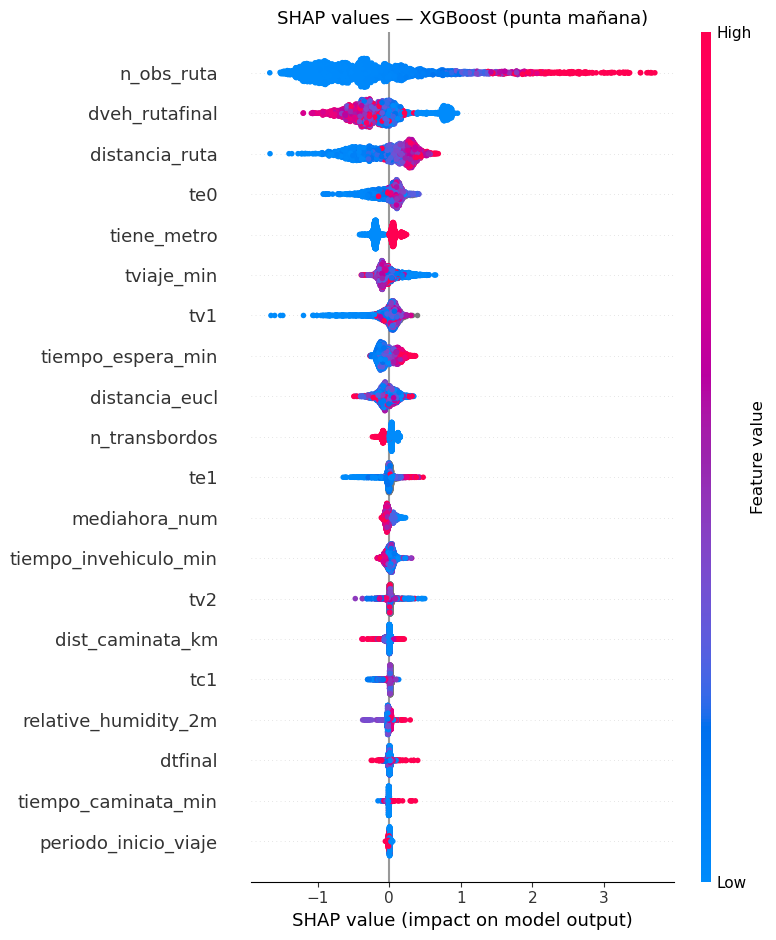

C:\Users\seba\AppData\Local\Temp\ipykernel_33924\3395781672.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_xgb, X_shap, feature_names=FEATURES_XGB, plot_type="bar", show=False)


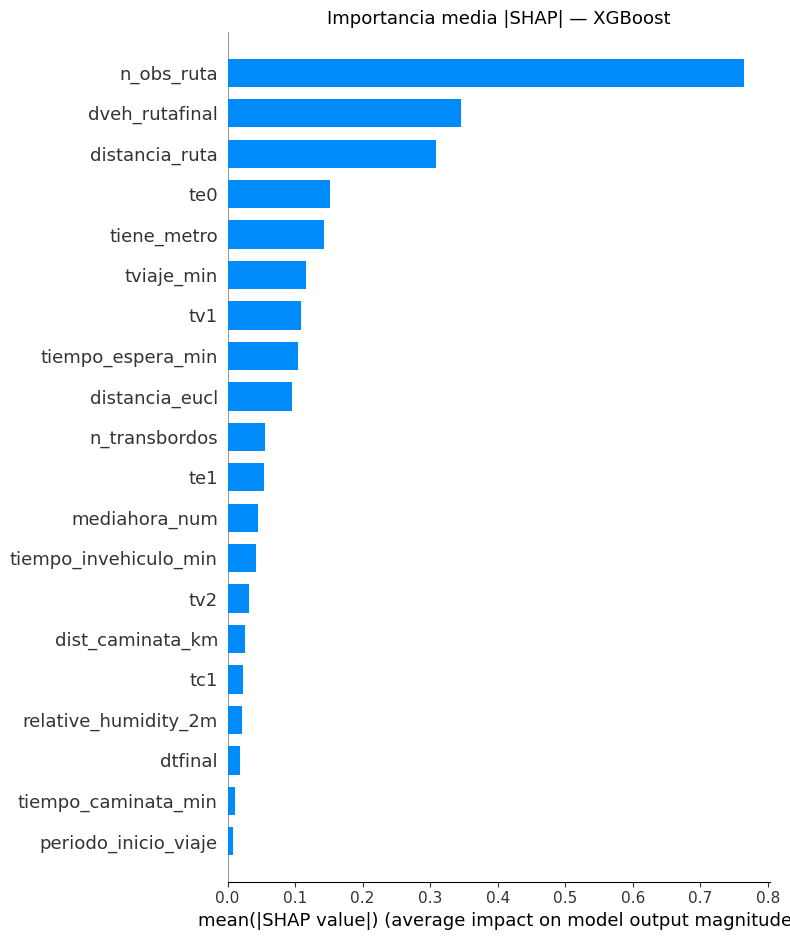


Importancia media |SHAP| por variable:
              feature  mean_abs_shap
           n_obs_ruta       0.765432
       dveh_rutafinal       0.346324
       distancia_ruta       0.308709
                  te0       0.151585
          tiene_metro       0.142357
           tviaje_min       0.116645
                  tv1       0.108441
    tiempo_espera_min       0.104974
       distancia_eucl       0.095558
        n_transbordos       0.055464
                  te1       0.054485
        mediahora_num       0.044666
tiempo_invehiculo_min       0.041945
                  tv2       0.031244
     dist_caminata_km       0.025075
                  tc1       0.023048
 relative_humidity_2m       0.020743
              dtfinal       0.017942
  tiempo_caminata_min       0.011208
 periodo_inicio_viaje       0.008561
       temperature_2m       0.007535
       wind_speed_10m       0.004838
                  tv3       0.000227
                  tc2       0.000196
                  te2       0.00017

In [9]:
import shap
import matplotlib.pyplot as plt

N_SHAP   = 3000
rng_shap = np.random.default_rng(RANDOM_STATE)
idx_shap = rng_shap.choice(len(X_test_xgb), N_SHAP, replace=False)
X_shap   = X_test_xgb[idx_shap]

print(f"Calculando SHAP values sobre muestra de {N_SHAP} observaciones...")
explainer_xgb   = shap.TreeExplainer(modelo_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_shap)

# TreeExplainer con XGBoost retorna array 2D (n_obs, n_feat) directamente
if isinstance(shap_values_xgb, np.ndarray) and shap_values_xgb.ndim == 3:
    sv_xgb = shap_values_xgb[:, :, 1]
else:
    sv_xgb = shap_values_xgb

print(f"  Shape SHAP: {sv_xgb.shape}  → esperado ({N_SHAP}, {len(FEATURES_XGB)})")

# Beeswarm
shap.summary_plot(sv_xgb, X_shap, feature_names=FEATURES_XGB, show=False)
plt.title("SHAP values — XGBoost (punta mañana)", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "xgb_02_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar
shap.summary_plot(sv_xgb, X_shap, feature_names=FEATURES_XGB, plot_type="bar", show=False)
plt.title("Importancia media |SHAP| — XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "xgb_02_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap_mean_xgb = pd.DataFrame({
    "feature":       FEATURES_XGB,
    "mean_abs_shap": np.abs(sv_xgb).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nImportancia media |SHAP| por variable:")
print(shap_mean_xgb.to_string(index=False))
